<a href="https://colab.research.google.com/github/setu-uiu/Finger-Vein-Recognition/blob/main/NUPT_FPV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving NUPT-FPV FINGER.zip to NUPT-FPV FINGER.zip


In [2]:
import zipfile
import os

zip_path = "/content/NUPT-FPV FINGER.zip"
extract_path = "/content/NUPT-FPV"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")
print(os.listdir(extract_path))

Dataset extracted!
['NUPT-FPV FINGER VEINS']


In [3]:
import os

dataset_path = "/content/NUPT-FPV/NUPT-FPV FINGER VEINS"

print("Dataset path:")
print(dataset_path)

print("\nInside dataset:")

for item in os.listdir(dataset_path):
    print(item)

Dataset path:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS

Inside dataset:
FingerVein
FingerVein 1


In [7]:
import os

dataset_path = "/content/NUPT-FPV/NUPT-FPV FINGER VEINS"

target_folder = "002"

for root, dirs, files in os.walk(dataset_path):

    if os.path.basename(root) == target_folder:

        print("FOUND FOLDER:")
        print(root)

        print("\nImages:")

        for file in sorted(files):

            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):

                print(os.path.join(root, file))

FOUND FOLDER:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002

Images:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_01.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_02.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_03.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_04.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_05.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_06.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_07.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_08.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_09.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/002/002_10.bmp
FOUND FOLDER:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein 1/002

Images:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein 1/002/002_01.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein 1/002/002_02.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/Finger

In [8]:
import os

dataset_path = "/content/NUPT-FPV/NUPT-FPV FINGER VEINS"

# First image automatically find
image_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            image_files.append(os.path.join(root, file))

print("Total images:", len(image_files))

# First image path
image_path = sorted(image_files)[0]

print("Selected image:")
print(image_path)

Total images: 400
Selected image:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein 1/001/001_01.bmp


Image size: (300, 450)
Image mode: L


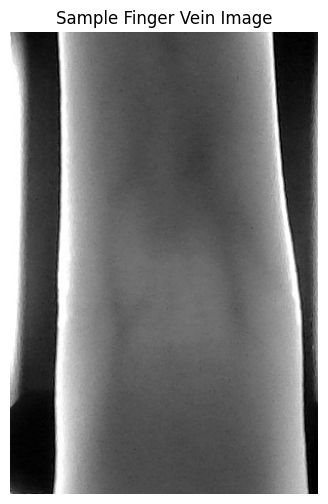

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Sample Finger Vein Image")
plt.axis("off")
plt.show()

In [10]:
import os

target = "003_01"

dataset_path = "/content/NUPT-FPV/NUPT-FPV FINGER VEINS"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.startswith(target):
            print("FOUND:")
            print(os.path.join(root, file))

FOUND:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/003/003_01.bmp
FOUND:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein 1/003/003_01.bmp


In [11]:
import os

dataset_path = "/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein"

target = "003_01"

found_path = None

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        name_without_ext = os.path.splitext(file)[0]

        if name_without_ext == target:
            found_path = os.path.join(root, file)
            break

    if found_path:
        break

print("FOUND:")
print(found_path)

FOUND:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/003/003_01.bmp


Image size: (300, 450)
Image mode: L


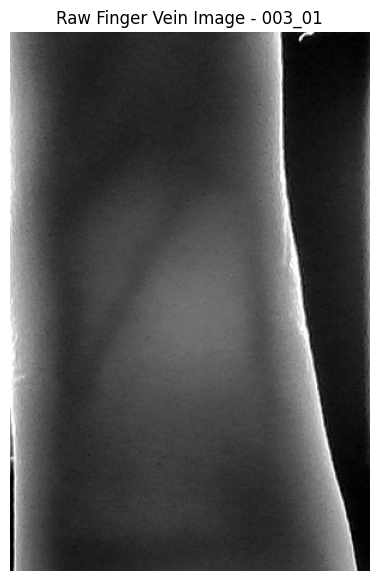

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(found_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 7))

plt.imshow(image, cmap="gray")

plt.title("Raw Finger Vein Image - 003_01")

plt.axis("off")

plt.show()

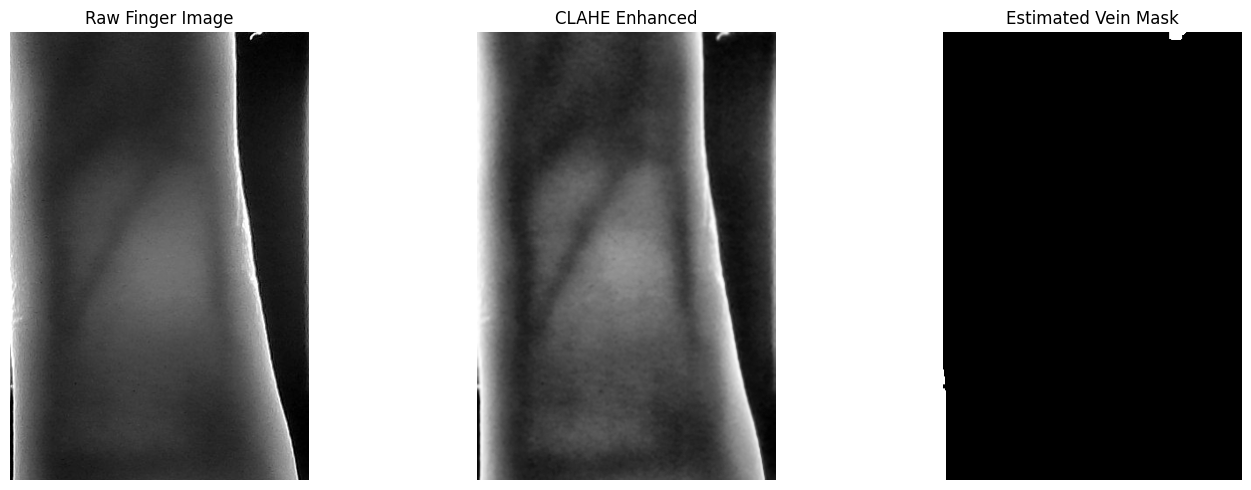

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Read image
img = cv2.imread(found_path, cv2.IMREAD_GRAYSCALE)

# 1. Gaussian Blur
blur = cv2.GaussianBlur(img, (5, 5), 0)

# 2. CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced = clahe.apply(blur)

# 3. Blackhat morphology
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (15, 15)
)

blackhat = cv2.morphologyEx(
    enhanced,
    cv2.MORPH_BLACKHAT,
    kernel
)

# 4. Threshold
_, vein_mask = cv2.threshold(
    blackhat,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Raw Finger Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(vein_mask, cmap="gray")
plt.title("Estimated Vein Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Mask shape: (450, 300)
Skeleton shape: (450, 300)
Skeleton pixels: 1261


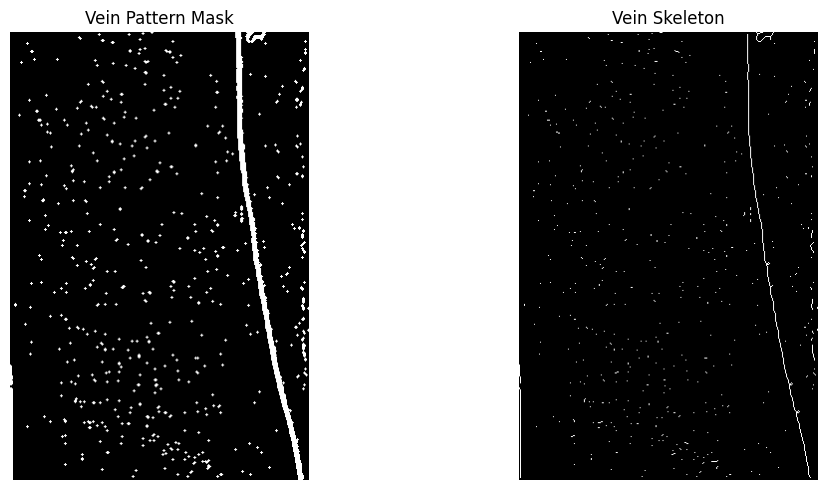

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

# Convert mask to NumPy array
mask_array = np.array(vein_mask)

# Binary mask
binary_mask = mask_array > 0

# Skeletonization
skeleton = skeletonize(binary_mask)

print("Mask shape:", binary_mask.shape)
print("Skeleton shape:", skeleton.shape)
print("Skeleton pixels:", skeleton.sum())

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(binary_mask, cmap="gray")
plt.title("Vein Pattern Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(skeleton, cmap="gray")
plt.title("Vein Skeleton")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
from scipy.ndimage import convolve

# Convert skeleton to 0/1
skeleton_uint = skeleton.astype(np.uint8)

# 8-neighborhood kernel
kernel = np.ones((3, 3), dtype=np.uint8)
kernel[1, 1] = 0

# Count neighboring skeleton pixels
neighbor_count = convolve(
    skeleton_uint,
    kernel,
    mode="constant",
    cval=0
)

# Junction = 3 or more neighboring connections
junctions = skeleton & (neighbor_count >= 3)

print("Number of junction pixels:", junctions.sum())

Number of junction pixels: 27


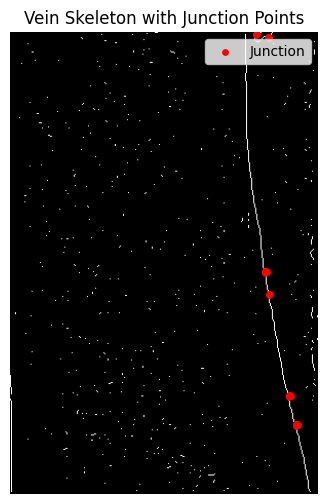

In [19]:
plt.figure(figsize=(12, 6))

plt.imshow(skeleton, cmap="gray")

# Get junction coordinates
y, x = np.where(junctions)

plt.scatter(
    x,
    y,
    c="red",
    s=15,
    label="Junction"
)

plt.title("Vein Skeleton with Junction Points")
plt.axis("off")
plt.legend()

plt.show()

Image path: /content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/003/003_02.bmp
Image size: (300, 450)
Image mode: L


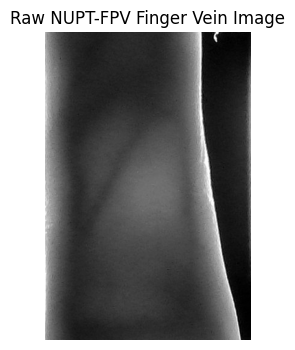

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# Your NUPT-FPV dataset path
base_path = "/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein"

# Select subject/folder
subject = "003"

# Select image
image_name = "003_02"

# Find image automatically
image_path = None

for ext in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]:
    test_path = os.path.join(base_path, subject, image_name + ext)

    if os.path.exists(test_path):
        image_path = test_path
        break

print("Image path:", image_path)

if image_path is None:
    print("Image not found!")
else:
    raw_image = Image.open(image_path).convert("L")

    print("Image size:", raw_image.size)
    print("Image mode:", raw_image.mode)

    plt.figure(figsize=(6, 4))
    plt.imshow(raw_image, cmap="gray")
    plt.title("Raw NUPT-FPV Finger Vein Image")
    plt.axis("off")
    plt.show()

Original minimum: 0.0
Original maximum: 255.0
Normalized minimum: 0.0
Normalized maximum: 1.0


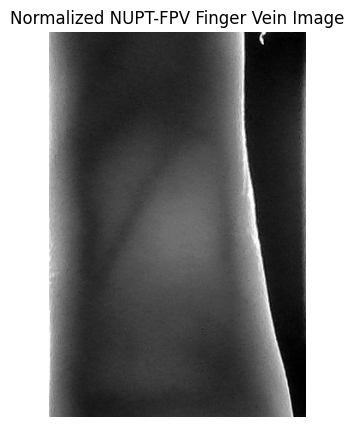

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Convert image to NumPy array
raw_array = np.array(raw_image, dtype=np.float32)

# Normalize pixel values to 0-1
normalized_image = raw_array / 255.0

# Pixel statistics
print("Original minimum:", raw_array.min())
print("Original maximum:", raw_array.max())

print("Normalized minimum:", normalized_image.min())
print("Normalized maximum:", normalized_image.max())

# Display normalized image
plt.figure(figsize=(8, 5))

plt.imshow(normalized_image, cmap="gray")

plt.title("Normalized NUPT-FPV Finger Vein Image")

plt.axis("off")

plt.show()

Original size: (300, 450)
Resized size: (128, 128)


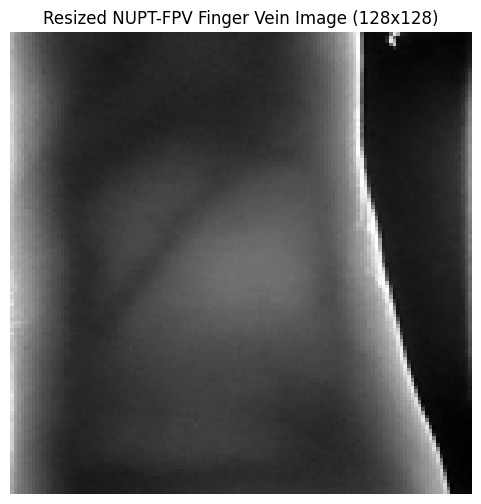

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

# Resize your NUPT-FPV raw image
resized_image = raw_image.resize((128, 128))

# Check image size
print("Original size:", raw_image.size)
print("Resized size:", resized_image.size)

# Display resized image
plt.figure(figsize=(6, 6))

plt.imshow(resized_image, cmap="gray")

plt.title("Resized NUPT-FPV Finger Vein Image (128x128)")

plt.axis("off")

plt.show()

In [25]:
import os

# NUPT-FPV dataset folder
raw_folder = "/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein"

# Store all image paths
image_files = []

# Find all images inside all subject folders
for root, dirs, files in os.walk(raw_folder):

    for file in files:

        if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):

            image_files.append(os.path.join(root, file))


# Total number of images
print("Total images found:", len(image_files))

# Show first 10 images
print("\nFirst 10 images:")

for path in image_files[:10]:
    print(path)

Total images found: 200

First 10 images:
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_07.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_06.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_10.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_09.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_01.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_02.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_05.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_08.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_03.bmp
/content/NUPT-FPV/NUPT-FPV FINGER VEINS/FingerVein/018/018_04.bmp
